# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [46]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') 
usage = pd.read_csv('/datasets/usage.csv') 

In [48]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [49]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [50]:
# mostrar las primeras 5 filas de usage
usage.shape[0]

40000

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [51]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [52]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [53]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [54]:

# inspección de usage con .info()

usage.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [55]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [56]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

- **Dataset users**

              - city con 469 valores faltantes que representan el 11.72% de los 40000 registros en total.
              - churn_date con 3534 valores faltantes que representan el 88.35% de los 40000 registros en total.

  
- **Dataset usage**

              - date con 50 valores faltantes que representan el 0.12% de los 40000 registros en total.
              - duration con 22076 valores faltates que representan el 55.19% de los 40000 registros en total.
              - lenght con 17896 valores faltantes que representan el 44.74% de los 40000 registros en total.

  

- Indica qué harías: ¿imputar, eliminar, ignorar?
  
**Dataset users**

              - city: investigar a que se deben los nulos para poder imputar.
              - churn_date: debido al gran porcentaje de ausentes lo conveniente es ignorarlos.

**Dataset usage**

              - date: tiene un porcentaje muy bajo de valores faltantes que ni siquiera llega al 1%, ignorarlos no afectaría al análisis del negocio.
              - duration: tiene un porcentaje por arriba del 55%, sin embargo, el hecho es que corresponde a los registros de texto donde la duración de llamada no existe, por lo que estos datos ignorarlos no tiene impacto negativo en el análisis. Lo recomendable sería dejarlos nulos o imputar con la media o la mediana.
              - lenght: su porcentaje también es elevado, en cambio, es una situación similar al caso de 'duration', aquí se registra el total de carácteres en un mensaje de texto que para el caso de una llamada no tiene relación alguna esta columna. Ignorarlos no tiene impacto, dejarlos nulos o imputar con la media o la mediana es la decisión más conveniente.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [57]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene el mismo valor para el promedio y la mediana, lo cual hace que la desviación estandar sea equivalente y no tan dispersa en los valores con relación a la mediana.
- La columna `age` tiene sentinels, se puede determinar debido a que el la descripción estadística tiene '-999' como valor mínimo, además en la media y la mediana existe una diferencia considerable entre valores. 

In [58]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran un comportamiento de valores normal donde la media y la mediana tienen el mismo valor, haciendo así un dataset confiable partiendo de estas dos columnas.
- Las columnas `duration` y `length` como se mencionó anteriormente tienen una relación diferente para cada tipo de comunicación. Para ConnectaTel sería absurdo tener un dataset para cada tipo de comunicación, aunque al igual que los identificadores (`id` y `user_id`) tendrían un comportamiento normal de manera visual inmediata.

In [59]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
      print(users[col].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene nombres abreviados de algunas ciudades y un registro como '?'. Todos los datos como enteros.
- La columna `plan` sólo cuenta con dos tipos de registro con tipo de dato entero.

In [60]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no existen valores atípicos y la información concuerda con los 40000 registros del dataset.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

          **Dataset users**

                      -Columna 'city': existen valores inesperados, siendo identificados como '?'.
- ¿Qué acción tomarías?

           Los sustituiría por valores NA.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [61]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce') # completa el código

In [62]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce') # completa el código

In [63]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, contiene registros para un futuro año correspondiente al análisis, a lo que implica establecerlo como fecha imposible. También la similitud entre las veces que se repiten los años 2022, 2023 y 2024 es muy similar una con la otra no hay un sesgo evidente por año de registro.

In [64]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, sólo se tiene información del comportamiento de los usuarios durante 2024. Eso significa que:

    -No se puede saber cómo se usaban los servicios en 2022 o 2023
    -El análisis de comportamiento estará acotado a 2024, independientemente de cuándo se registraron
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) **SÍ**
- ¿Qué harías con ellas? **Sustituirlas por nulos, cuenta con un registro de 40 usuarios (no afecta en el análisis).**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [65]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = np.where(users['age'] == -999, age_mediana, users['age'])

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [66]:
# Reemplazar ? por NA en city
users['city'] = np.where(users['city'] == '?', pd.NA, users['city'])
# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [67]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [68]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [69]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diágnostico de nulos en `duration` y `length`. Los nulos en verdad son MACR debido a que para este dataset se registra el tipo de comunicación, ya sea por llamada o mensaje. La columna length se atribuye a mensaje, refireindose a la cantidad de carácteres dentro del texto enviado cosa que para una llamada no podría ser de esta manera, por eso es que existe una columna que se llama duration donde se registra el tiempo total de la llamada. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [70]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(usage['user_id']).agg(cant_mensajes = ('is_text', 'sum'), cant_llamadas = ('is_call', 'sum'), cant_minutos_llamada = ('duration', 'sum')).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [71]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [72]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on = 'user_id', how = 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [73]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [74]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

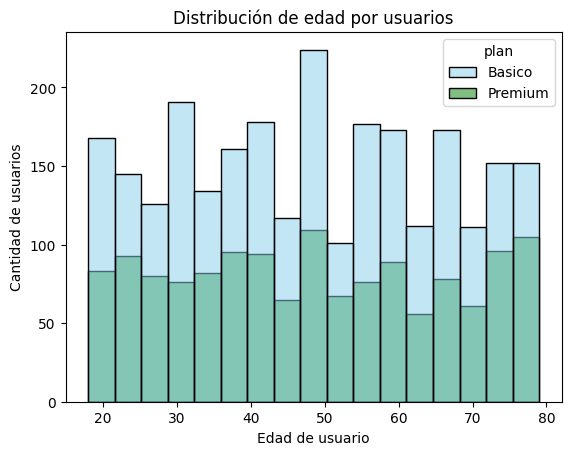

In [75]:
# Histograma para visualizar la edad (age)


sns.histplot(data = user_profile, x = 'age', hue = 'plan', palette = ['skyblue','green'])
plt.title('Distribución de edad por usuarios')
plt.xlabel('Edad de usuario')
plt.ylabel('Cantidad de usuarios')
plt.show()



💡Insights: 
- La distribución es uniforme, evidenciando que todas las edades tienen una probabilidad similar de aparecer en los datos, y además el plan básico tiene al menos el doble de usuarios que el premium en la mayoría de los rangos de edad.

Con la información en las columnas (gb_per_month, messages_included, minutes_included y usd_monthly_pay ) del dataset 'plans'  se observa que el plan básico está por mucho muy debajo del 50% de los servicios del plan premium, a excepción del pago mensual. El pago por mes del premium es de 25 usd y el básico de 12 usd; 13 usd más de diferencia, no existe proporcionalidad en los beneficios. También se observa en la columna churn_date en el datset 'users' existe abandono de usuarios. Los riesgos identificados son, las ofertas de la competencia, el crecimiento de otras líneas telefónicas y la portabilidad de número como ventaja en este mercado para el cliente evita dificultades al realizar un cambio de compañía. Se sugiere aumentar los beneficios en el plan básico, así como también el precio mensual en proporción al incremento en los servicios.

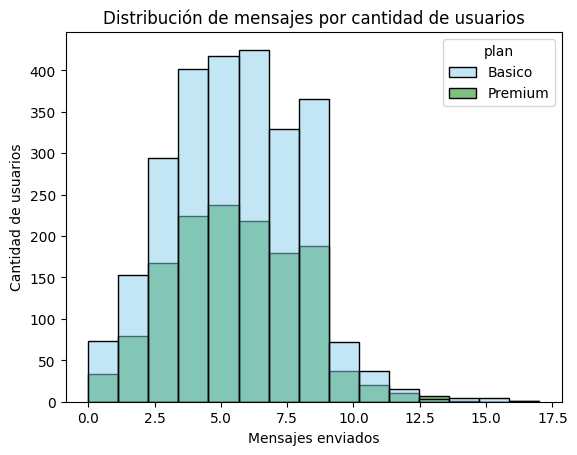

In [76]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data = user_profile, x = 'cant_mensajes', bins = 15, hue = 'plan', palette = ['skyblue','green'])
plt.title('Distribución de mensajes por cantidad de usuarios')
plt.xlabel('Mensajes enviados')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- La distribución de mensajes se sesga hacia la derecha, indicando casos en usuarios que enviaron mensajes en cantidades del doble o más por encima de la mediana, es decir, el mayor número de usuarios envió entre 5 y 6 mensajes, y en ese rango la proporción del plan básico es mayor a 0.10, mientras que para el plan premium es de entre 0.057 y 0.06.

Los servicios en general están muy sobrados para lo que demanda el cliente, posiblemente usen otro método de comunicación. 

El riesgo sería que existan planes de telefonía más ajustados a la navegación en lugar de la comunicación convencional. Aquí la prioridad de uso no está siendo definida por estos modos de comunicación; considerar la calidad de cobertura. Con esto impulsar a ConnectaTel a desarrollar ajustes en los planes ofrecidos.

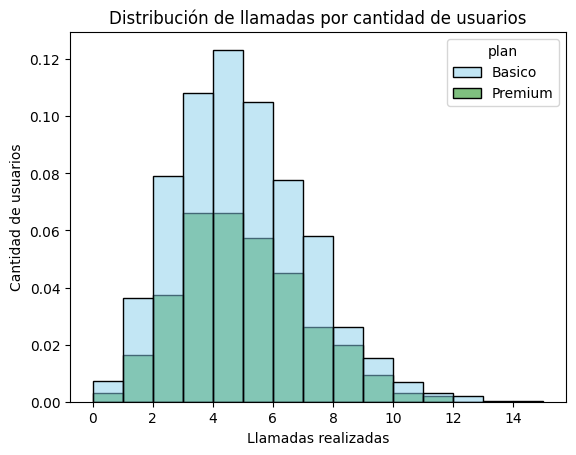

In [77]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data = user_profile, x = 'cant_llamadas', stat = 'probability', bins = 15, hue = 'plan', palette = ['skyblue','green'])
plt.title('Distribución de llamadas por cantidad de usuarios')
plt.xlabel('Llamadas realizadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- El histograma de distribución de llamadas por cantidad de usuarios evidencia un sesgo a la derecha donde sólo una minoría hace mucho más de la mayoría. En el rango de 3-5 llamadas, la proporción de usuarios del plan Básico es mayor que la del Premium, lo que indica que ConnectaTel podría partir de este hallazgo para reajustar esos 600 minutos que está otrogando al usuario premium.

En general la mayoría de los usuarios no aprovecha del todo su plan, donde los factores podrían ser una cobertura ineficiente, o alternativas como WhatsApp o Telegram. A pesar de esto sí existen 17 casos de clientes con plan básico que superan los 100 minutos de su respectivo contrato.

Basandose en ello implicaría hacer un ajuste en el servicio de llamadas donde en lugar de determinar un límite de minutos hacerlo ilimitado a un determinado número de llamadas partiendo del percentil 75 = 6 llamadas como umbral, ya que protege al 75% de los usuarios actuales, reduciendo la fricción y favoreciendo la retención de clientes, mientras que el 25% restante que supere ese límite generaría ingresos adicionales para ConnectaTel.

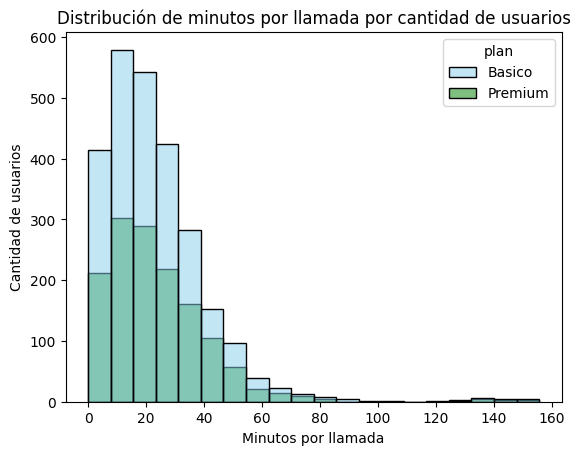

In [78]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data = user_profile, x = 'cant_minutos_llamada', bins = 20, hue = 'plan', palette = ['skyblue','green'])
plt.title('Distribución de minutos por llamada por cantidad de usuarios')
plt.xlabel('Minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- El histograma de distribución por cantidad de minutos por llamada del 2024 muestra sesgo a la derecha. Esto indica que la mayoría de los usuarios se concentra en el rango de 0-20 minutos, y que hay pocos usuarios con llamadas de muy larga duración (cerca de 140-160 minutos). Aunque los usuarios del plan básico predominan en el dataset, las cifras por uso son muy bajas para dicho período.

Entre los factores que podrían influir se encuentran preferencia por apps de mensajería, agotamiento de datos, llamadas a fijos o servicios, entre otros.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráficos, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

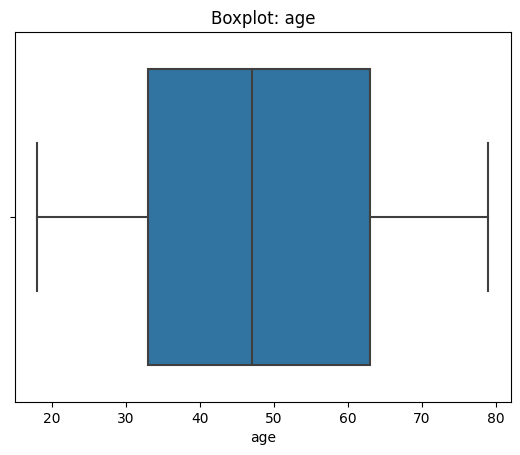

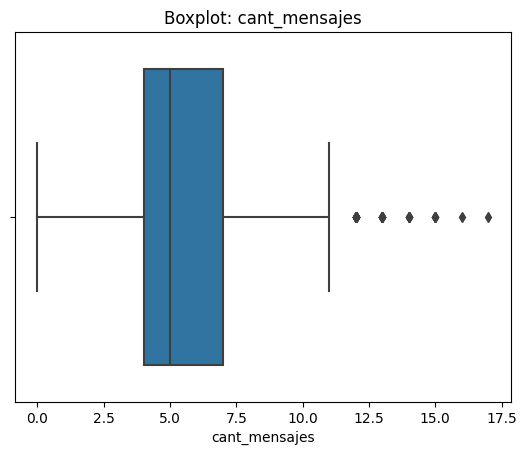

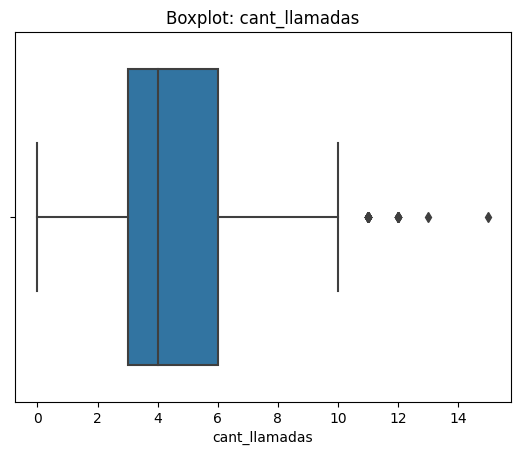

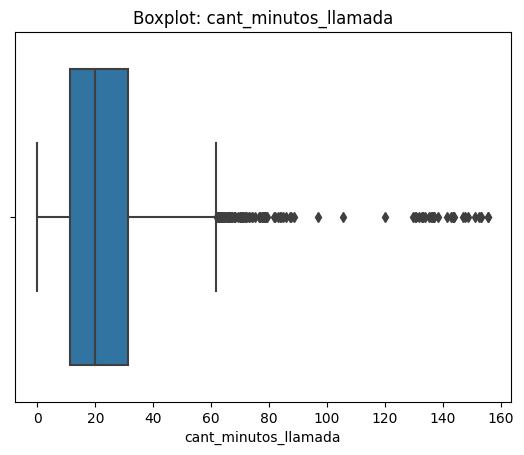

In [79]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data = user_profile, x = col, hue = 'plan')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: Sí presenta outliers
- cant_llamadas: Sí presenta outliers
- cant_minutos_llamada: Sí presenta outliers

In [80]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
Q1 = user_profile[columnas_limites].quantile(0.25)
Q3 = user_profile[columnas_limites].quantile(0.75)
upper = {}
lower = {}

for col in columnas_limites:
    IQR = Q3[col] - Q1[col]
    upper[col] = Q3[col] + 1.5*IQR
    print("\nLimite superior en:", col, upper[col])
    lower[col] = Q1[col] - 1.5*IQR
    print("Limite inferior en:", col, lower[col])




Limite superior en: cant_mensajes 11.5
Limite inferior en: cant_mensajes -0.5

Limite superior en: cant_llamadas 10.5
Limite inferior en: cant_llamadas -1.5

Limite superior en: cant_minutos_llamada 61.8575
Limite inferior en: cant_minutos_llamada -19.322500000000005


In [81]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

          -Mantener los outliers, porque en si eliminarlos no mejora ni distociona el perfil real de los clientes.
  
- cant_llamadas: mantener o no outliers, porqué?

          -Mantener los outliers ayuda a comprender de dónde provienen esas cantidades altas de llamadas, es decir, que plan es mejor aprovechado.

  
- cant_minutos_llamada: mantener o no outliers, porqué?

          -Eliminar los outliers conduciría a no saber en que casos se está dando un alto uso de minutos en llamadas. Recordar que un plan contiene 100 minutos y otro 600, mientras que en el boxplot sólo se evidencia un limite de aproximadamente 61 minutos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), "Bajo uso", np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), "Uso medio", "Alto uso"))

In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [84]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30, "Joven", np.where(user_profile['age'] < 60, "Adulto", "Adulto mayor"))

In [85]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

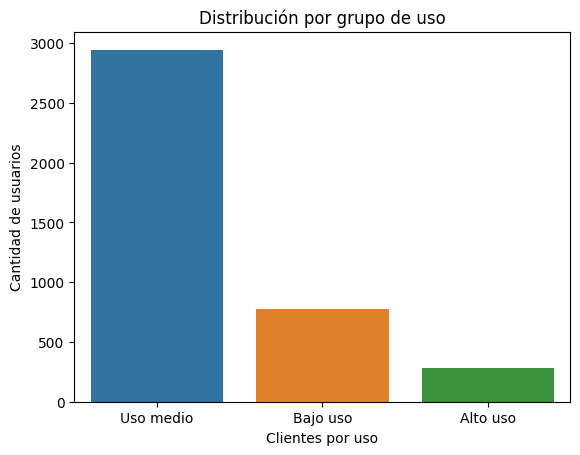

In [86]:
# Visualización de los segmentos por uso

sns.countplot(data = user_profile, x = 'grupo_uso', order = user_profile['grupo_uso'].value_counts().index)
plt.title('Distribución por grupo de uso')
plt.xlabel('Clientes por uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

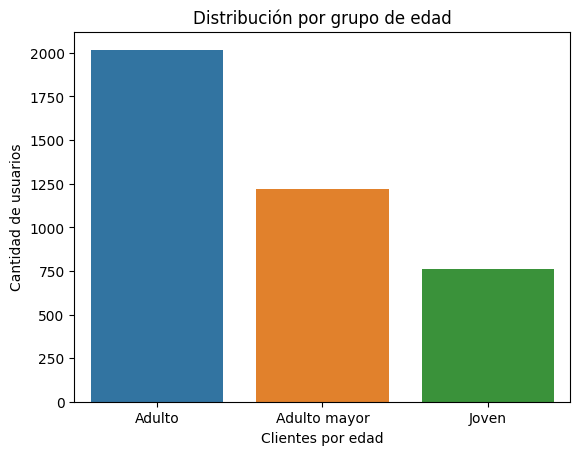

In [87]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x = 'grupo_edad', order = user_profile['grupo_edad'].value_counts().index)
plt.title('Distribución por grupo de edad')
plt.xlabel('Clientes por edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos** 
- **Dataset users:**

      -Columna city con 469 valores faltantes que representan el 11.72% de los 4000 registros en total, se propone investigar esos nulos para poder realizar imputación. También aparecieron datos invalidos con nombres abreviados de algunas ciudades y un registro de datos como '?' que posteriormente se sutituyeron por NA.
      -Columna churn_date con 3534 valores faltantes que representan el 88.35% de los 4000 registros en total, los nulos aquí evidencian que aún hay gran cantidad de usuarios activos.
      -Columna reg_date existen valores futuros, 40 registros para 2026. Se definió como fecha imposible para después marcarlas como nulas.
      -Columna age tiene sentinels, se puede determinar debido a que el la descripción estadística tiene '-999' como valor mínimo, además en la media y la mediana existe una diferencia considerable entre valores. Se sustituyeron con la mediana.


- **Dataset usage:**

      -Columna date con 50 valores faltantes que representan el 0.12% de los 40000 registros en total. El porcentaje en este caso fue muy bajo que ni siqiera llegó al 1% por lo que se decidió ignorarlo.
      -Columna duration con 22076 valores faltates que representan el 55.19% de los 40000 registros en total. Un porcentaje alto de valores nulos que fue ignorado a causa de que son registros correspondientes a mensajes, que en si no se mide la duración de los mismos.
      -Columna lenght con 17896 valores faltantes que representan el 44.74% de los 40000 registros en total.  Los nulos se ignoraron por razón similar a la de los mensajes, aquí los faltantes corresponden a registros de llamadas que en este caso no se pueden registrar los carácteres de una llamada.


🔍 **Segmentos por Edad**
- El grupo de edad más grande es el de adultos, y el más pequeño es el de jovenes. ConnectaTel tiene garantizado una gran demanda de personas adultas.
- Se esperaría que el grupo de edad juvenil fuera el que más demanda tuviera en el dataset. Considerar que sólo se analizaron cantidades de mensajes y llamadas, y al llegar a este countplot nos acercamos a la idea de que  por uso los adultos predominan en la base de datos de ConnectaTel.
  
📊 **Segmentos por Nivel de Uso**
- El uso medio predomina en los clientes, aunque el impacto está en los usuarios de alto uso, que a pesar de ser una cantidad pequeña demuestran la gran fidelidad a la línea.

➡️ Esto sugiere que ... 
-  ConnectaTel debe implementar una estartegia para atraer más clientes jovenes que es donde se esperaría tener mayor número de usuarios, esto mediante un ajuste en la cantidad de GB que se ofrece por mes.
  
-  ConnectaTel debe de estudiar las razones de uso medio y alto para así desarrollar un método que impulse a contrarestar esa distribución de uso medio a alto. La diferencia es que al cliente (uso medio) que se busca impulsar a usar más la línea podría adquirir el plan premium donde los beneficios son mucho más elevados a el básico con una cantidad de 100 minutos por mes que ya se mencionó que existen casos donde usuarios han excedido el límite de llamadas y de esta manera aprovechar en su máximo los servicios en el plan premium.

💡 **Recomendaciones**
- Existen 17 usuarios que excedieron el plan básico, se sugiere llevar a cabo una oferta temporal de goce con plan premium a un precio exclusivo, así el usuario se involucraría mucho más con los beneficios. De no convencerlo el patrón de observar que se realiza un pago adicional por mes no se vería afectado.
- En el plan básico hay que ajustar el número de minutos a minutos ílimitados para un determinado límite de llamadas. Con el plan premium lo mismo, pero con una cantidad superior en llamadas.
- Hacer un registro de cuántos GB en su respectivo plan de cada usuario ayudaría a saber si los numeros bajos en mensajes y llamadas se deben a la posibiladad de consumo total de los datos moviles por uso continuo de aplicaciones digitales (ej. WhatsApp o Telegram) como alternativa de comunicación.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`